In [11]:
# check installed version
import duckdb
import pycaret
pycaret.__version__

'3.3.2'

In [12]:
def clean_disp():
    res = pull()
    display(
        res.style
        .set_properties(**{
            "color": "#111",
            "background-color": "#fff"
        })
    )

def esql(query):
    return duckdb.sql(query).df()


# 🚀 Quick start

PyCaret's Clustering Module is an unsupervised machine learning module that performs the task of grouping a set of objects in such a way that objects in the same group (also known as a cluster) are more similar to each other than to those in other groups. 

It provides several pre-processing features that prepare the data for modeling through the setup function. It has over 10 ready-to-use algorithms and several plots to analyze the performance of trained models. 

A typical workflow in PyCaret's unsupervised module consist of following 6 steps in this order:

### **Setup** ➡️ **Create Model** ➡️ **Assign Labels** ➡️ **Analyze Model** ➡️ **Prediction** ➡️ **Save Model**

In [3]:
# loading sample dataset from pycaret dataset module
from pycaret.datasets import get_data
data = get_data('jewellery')

,Age,Income,SpendingScore,Savings
0,58,77769,0.791329,6559.829923
1,59,81799,0.791082,5417.661426
2,62,74751,0.702657,9258.992965
3,59,74373,0.765680,7346.334504
4,87,17760,0.348778,16869.507130


In [5]:
data.describe()

,Age,Income,SpendingScore,Savings
count,505.000000,505.000000,505.000000,505.000000
mean,59.019802,75513.291089,0.505083,11862.455867
std,24.140043,35992.922184,0.259634,4949.229253
min,17.000000,12000.000000,0.000000,0.000000
25%,34.000000,34529.000000,0.304792,6828.709702
50%,59.000000,75078.000000,0.368215,14209.932802
75%,85.000000,107100.000000,0.768279,16047.268331
max,97.000000,142000.000000,1.000000,20000.000000


## Setup
This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. It only has one required parameter i.e. `data`. All the other parameters are optional.

In [6]:
# import pycaret clustering and init setup
from pycaret.clustering import *
s = setup(data, session_id = 123,verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Original data shape,"(505, 4)"
2,Transformed data shape,"(505, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


Once the setup has been successfully executed it shows the information grid containing experiment level information. 

- **Session id:**  A pseudo-random number distributed as a seed in all functions for later reproducibility. If no `session_id` is passed, a random number is automatically generated that is distributed to all functions.<br/>
<br/>
- **Original data shape:**  Shape of the original data prior to any transformations. <br/>
<br/>
- **Transformed data shape:**  Shape of data after transformations <br/>
<br/>
- **Numeric features :**  The number of features considered as numerical. <br/>
<br/>
- **Categorical features :**  The number of features considered as categorical. <br/>

## Create Model

1. 주요 평가 지표 (Metric) 해석
K-Means는 정답(Label)이 없는 비지도 학습이므로, 얼마나 "잘 뭉치고 잘 떨어져 있는지"를 평가합니다.

Silhouette (실루엣 계수): 가장 중요한 지표입니다.
1에 가까울수록 군집화가 아주 잘 된 것이고, 0에 가까우면 군집 간 경계가 모호하며, 음수면 데이터가 잘못된 군집에 할당된 것입니다. (보통 0.5 이상이면 준수하다고 봅니다.)

Calinski-Harabasz (CH 지표): 군집 내 분산 대비 군집 간 분산을 측정합니다.
값이 클수록 군집화가 잘 된 것입니다.

Davies-Bouldin (DB 지표): 군집 간의 거리와 군집 내의 분산을 비교합니다.
값이 작을수록(0에 가까울수록) 군집 간의 분리가 잘 된 좋은 모델입니다.

Homogeneity (동질성) 등: 만약 setup 시 target을 지정했다면 나타나며, 실제 정답과 얼마나 일치하는지를 보여줍니다.

2. 기본 설정값 (Default)
별도의 파라미터 지정 없이 실행했다면, PyCaret은 기본적으로 4개의 군집(k=4)을 생성합니다.


In [7]:
# train kmeans model
kmeans = create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7207,5011.8115,0.4114,0,0,0


In [8]:
# to check all the available models
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


In [9]:
# train meanshift model
meanshift = create_model('meanshift')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7393,3567.5370,0.3435,0,0,0


## Assign Model
This function assigns cluster labels to the training data, given a trained model.

In [10]:
kmeans_cluster = assign_model(kmeans)
kmeans_cluster

,Age,Income,SpendingScore,Savings,Cluster
0,58,77769,0.791329,6559.830078,Cluster 2
1,59,81799,0.791082,5417.661621,Cluster 2
2,62,74751,0.702657,9258.993164,Cluster 2
3,59,74373,0.765680,7346.334473,Cluster 2
4,87,17760,0.348778,16869.507812,Cluster 1
...,...,...,...,...,...
500,28,101206,0.387441,14936.775391,Cluster 3
501,93,19934,0.203140,17969.693359,Cluster 1
502,90,35297,0.355149,16091.402344,Cluster 1
503,91,20681,0.354679,18401.087891,Cluster 1


In [19]:
query="""
select cluster, mean(age), mean(income), mean(spendingscore), mean(savings), count(*) cnt 
from kmeans_cluster 
group by cluster
order by cluster
"""
esql(query)

,Cluster,mean(age),mean(income),mean(spendingscore),mean(savings),cnt
0,Cluster 0,40.875000,126031.666667,0.654598,7287.926080,72
1,Cluster 1,87.775510,27866.102041,0.328800,16659.261393,147
2,Cluster 2,59.961538,72332.846154,0.771296,6890.893301,156
3,Cluster 3,35.423077,105228.392308,0.302153,14937.836478,130


## Analyze Model

You can use the `plot_model` function to analyzes the performance of a trained model on the test set. It may require re-training the model in certain cases.

In [20]:
# plot pca cluster plot 
plot_model(kmeans, plot = 'cluster')

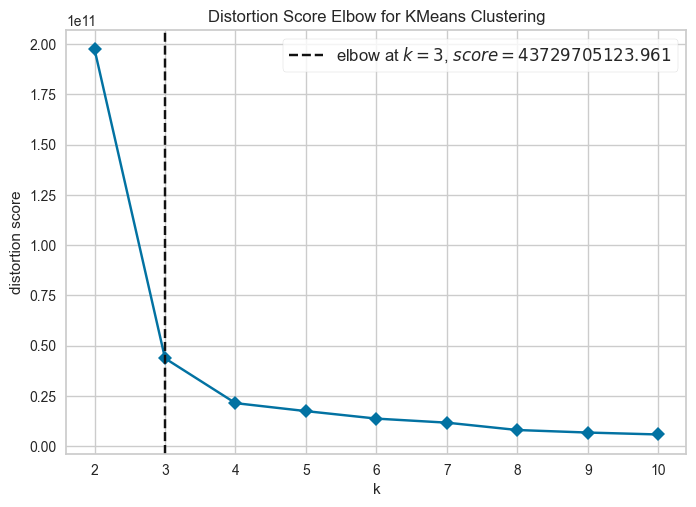

In [21]:
# plot elbow
plot_model(kmeans, plot = 'elbow')

1. 칼날의 길이 (실루엣 계수 값)
가로축(Silhouette coefficient values)은 -1에서 1 사이의 값을 가집니다.
개별 칼날(각 데이터)이 오른쪽(1에 가깝게)으로 길게 뻗어 있을수록 해당 데이터가 자기 군집에 아주 잘 속해 있다는 뜻입니다.
반대로 0 근처에 있거나 음수(-) 영역으로 뻗어 있다면, 다른 군집과 경계가 모호하거나 잘못 분류된 데이터가 있다는 신호입니다.

2. 빨간 점선 (평균 실루엣 점수)
그래프를 세로로 가로지르는 빨간 점선은 모든 데이터의 평균 실루엣 점수입니다.
이 점선이 0.5 이상이면 군집화가 상당히 잘 된 편으로 보며, 0.25 이하로 낮다면 군집 수를 조정하거나 데이터를 다시 살펴봐야 합니다.

3. 칼날의 두께와 모양 (군집별 균형)
세로폭(두께)은 각 군집에 속한 데이터의 개수를 의미합니다.
모든 군집의 두께가 비슷하다면 데이터가 균등하게 배분된 것이고, 특정 군집만 너무 얇거나 두껍다면 군집 불균형이 일어난 것입니다.
이상적인 그래프: 모든 칼날이 빨간 점선을 넘어서고, 모양이 뭉툭하지 않으며, 각 군집의 두께가 일정한 상태입니다.

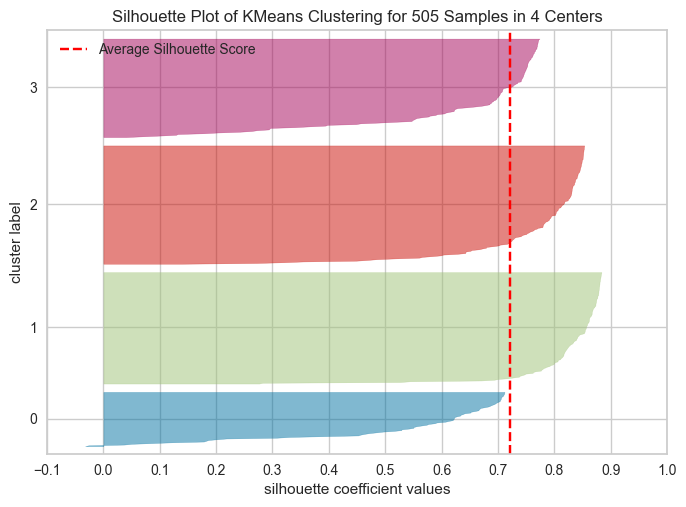

In [22]:
# plot silhouette
plot_model(kmeans, plot = 'silhouette')

In [23]:
evaluate_model(kmeans)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## Prediction
The `predict_model` function returns `Cluster` label as a new column in the input dataframe. This step may or may not be needed depending on the use-case. Some times clustering models are trained for analysis purpose only and the interest of user is only in assigned labels on the training dataset, that can be done using `assign_model` function. `predict_model` is only useful when you want to obtain cluster labels on unseen data (i.e. data that was not used during training the model).

In [24]:
# predict on test set
kmeans_pred = predict_model(kmeans, data=data)
kmeans_pred

,Age,Income,SpendingScore,Savings,Cluster
0,58.0,77769.0,0.791329,6559.829923,Cluster 2
1,59.0,81799.0,0.791082,5417.661426,Cluster 2
2,62.0,74751.0,0.702657,9258.992965,Cluster 2
3,59.0,74373.0,0.765680,7346.334504,Cluster 2
4,87.0,17760.0,0.348778,16869.507130,Cluster 1
...,...,...,...,...,...
500,28.0,101206.0,0.387441,14936.775389,Cluster 3
501,93.0,19934.0,0.203140,17969.693769,Cluster 1
502,90.0,35297.0,0.355149,16091.401954,Cluster 1
503,91.0,20681.0,0.354679,18401.088445,Cluster 1


## Save Model

Finally, you can save the entire pipeline on disk for later use, using pycaret's `save_model` function.

In [25]:
# save pipeline
save_model(kmeans, 'kmeans_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Age', 'Income', 'SpendingScore',
                                              'Savings'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('trained_model', KMeans(n_clusters=4, random_state=123))]),
 'kmeans_pipeline.pkl')

In [26]:
# load pipeline
kmeans_pipeline = load_model('kmeans_pipeline')
kmeans_pipeline

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Age', 'Income', 'SpendingScore',
                                             'Savings'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('trained_model', KMeans(n_clusters=4, random_state=123))])

# 👇 Detailed function-by-function overview

## ✅ Setup
This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. It only has one required parameter i.e. `data`. All the other parameters are optional.

In [27]:
# init setup
s = setup(data, session_id = 123,verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Original data shape,"(505, 4)"
2,Transformed data shape,"(505, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


To access all the variables created by the setup function such as transformed dataset, random_state, etc. you can use `get_config` method.

In [28]:
# check all available config
get_config()

{'USI',
 'X',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables'}

In [29]:
# lets access X_train_transformed
get_config('X_train_transformed')

,Age,Income,SpendingScore,Savings
0,58.0,77769.0,0.791329,6559.830078
1,59.0,81799.0,0.791082,5417.661621
2,62.0,74751.0,0.702657,9258.993164
3,59.0,74373.0,0.765680,7346.334473
4,87.0,17760.0,0.348778,16869.507812
...,...,...,...,...
500,28.0,101206.0,0.387441,14936.775391
501,93.0,19934.0,0.203140,17969.693359
502,90.0,35297.0,0.355149,16091.402344
503,91.0,20681.0,0.354679,18401.087891


In [30]:
# another example: let's access seed
print("The current seed is: {}".format(get_config('seed')))

# now lets change it using set_config
set_config('seed', 786)
print("The new seed is: {}".format(get_config('seed')))

The current seed is: 123
The new seed is: 786


In [32]:
# init setup with normalize = True

s = setup(data, session_id = 123,
          normalize = True, normalize_method = 'minmax', verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Original data shape,"(505, 4)"
2,Transformed data shape,"(505, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,minmax


<Axes: >

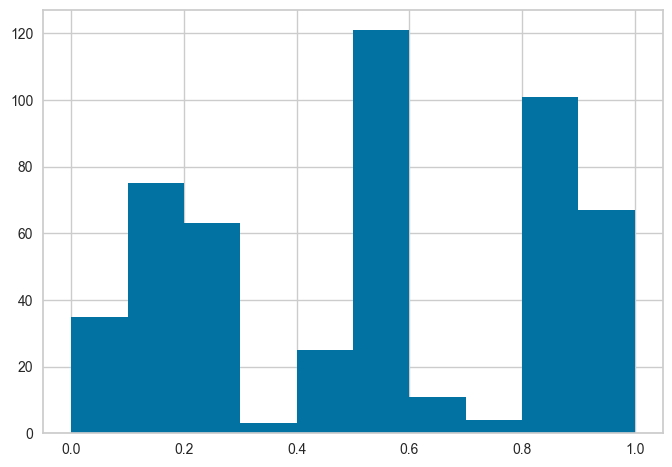

In [33]:
# lets check the X_train_transformed to see effect of params passed
get_config('X_train_transformed')['Age'].hist()

Notice that all the values are between 0 and 1 - that is because we passed `normalize=True` in the `setup` function. If you don't remember how it compares to actual data, no problem - we can also access non-transformed values using `get_config` and then compare. See below and notice the range of values on x-axis and compare it with histogram above.

<Axes: >

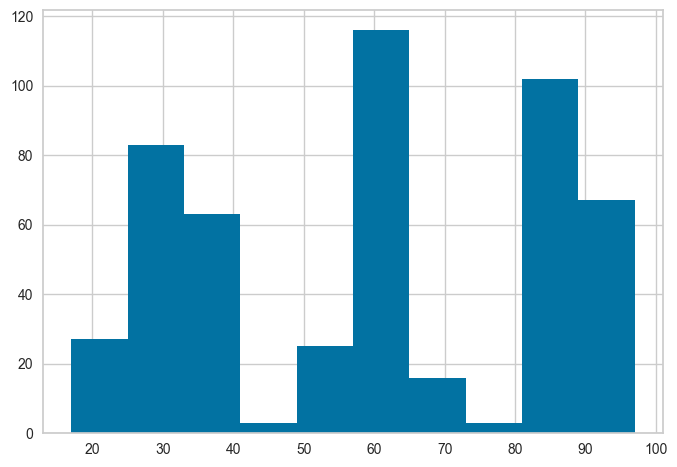

In [34]:
get_config('X_train')['Age'].hist()

## ✅ Create Model
This function trains and evaluates the performance of a given estimator using cross-validation. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function. All the available models can be accessed using the models function.

In [35]:
# train kmeans
kmeans = create_model('kmeans')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,02:31:57
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7274,1045.9028,0.4191,0,0,0


In [36]:
kmeans_results = pull()
print(type(kmeans_results))
kmeans_results

<class 'pandas.core.frame.DataFrame'>


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7274,1045.9028,0.4191,0,0,0


In [37]:
# train kmeans with 10 clusters
create_model('kmeans', num_clusters = 10)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2224,2174.5428,1.5598,0,0,0


KMeans(n_clusters=10, random_state=123)

## ✅ Assign Model
This function assigns cluster labels to the training data, given a trained model.

In [38]:
assign_model(kmeans)

,Age,Income,SpendingScore,Savings,Cluster
0,58,77769,0.791329,6559.830078,Cluster 1
1,59,81799,0.791082,5417.661621,Cluster 1
2,62,74751,0.702657,9258.993164,Cluster 1
3,59,74373,0.765680,7346.334473,Cluster 1
4,87,17760,0.348778,16869.507812,Cluster 2
...,...,...,...,...,...
500,28,101206,0.387441,14936.775391,Cluster 3
501,93,19934,0.203140,17969.693359,Cluster 2
502,90,35297,0.355149,16091.402344,Cluster 2
503,91,20681,0.354679,18401.087891,Cluster 2


## ✅ Plot Model
This function analyzes the performance of a trained model.

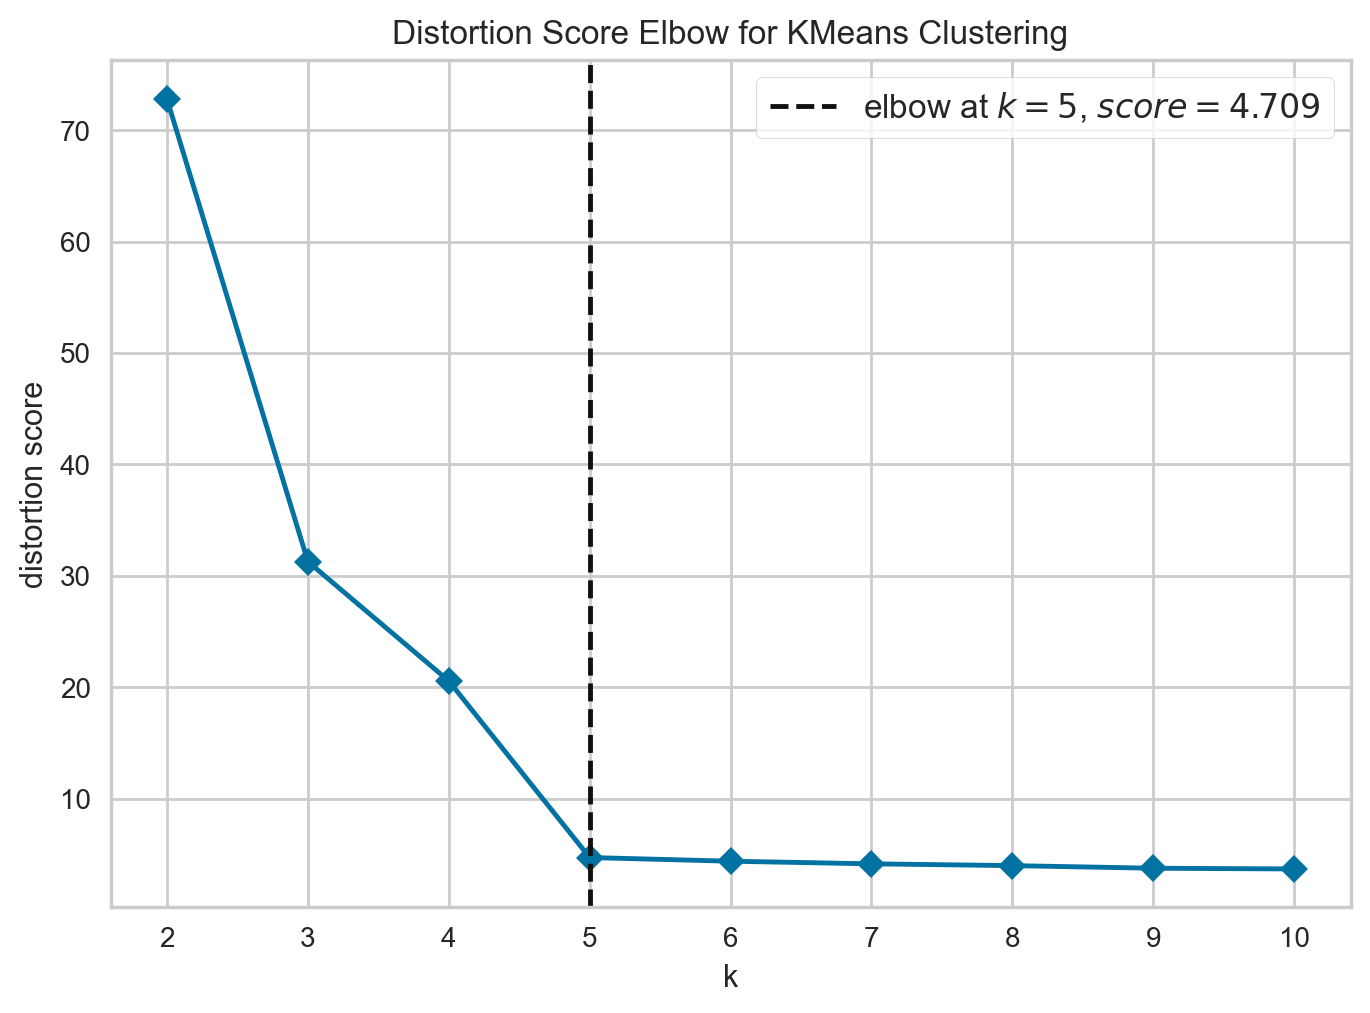

In [39]:
# to control the scale of plot
plot_model(kmeans, plot = 'elbow', scale = 2)

In [40]:
# to save the plot
plot_model(kmeans, plot = 'elbow', save=True)

'Elbow Plot.png'